# Diagnóstico General de Fuentes Base – EDA
## Avance 1: Análisis Exploratorio de Datos
**Planta:** LY78 – San Luis Potosí, BMW Group  
**Objetivo:** Analizar la calidad, estructura y distribuciones de las **fuentes base reales**
de Athena (no tablas derivadas/procesadas).

### Fuentes base analizadas

| # | Tabla Athena | Base de Datos | Descripción |
|---|---|---|---|
| 1 | `days_of_supply_historical` | otd_material_control_sem | Stock planta / historial DOS |
| 2 | `stock_and_requirement_list_detail_latest` | otd_stock_req_list_sem | Snapshot más reciente demanda/stock |
| 3 | `header_position_p30` | otd_inbound_delivery_2_sem | ASN / entregas inbound |
| 4 | `material_master` | otd_material_master_sem | Maestro de materiales |
| 5 | `material_master_historical` | otd_material_master_sem | Histórico MRP / concepto |
| 6 | `te_planorder_volume_daily` | otd_ppcm_sem | Demanda primaria (plan orders) |
| S3 | RunOut / Price / Boxqty | s3://runoutbucket | Datos complementarios Excel |

> **Variable objetivo:** Days of Supply (DOS) — se puede calcular desde
> `days_of_supply_historical` **y** desde `stock_and_requirement_list`, pero los valores
> varían por diferencias en la lógica de cálculo.

In [1]:
%pip install -q awswrangler

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
amazon-sagemaker-sql-editor 0.1.16 requires aiobotocore<3,>=2.7.0, but you have aiobotocore 3.5.0 which is incompatible.
aiobotocore 3.5.0 requires botocore<1.42.92,>=1.42.90, but you have botocore 1.34.162 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -q openpyxl

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install -q s3fs

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
amazon-sagemaker-sql-editor 0.1.16 requires aiobotocore<3,>=2.7.0, but you have aiobotocore 3.5.0 which is incompatible.
boto3 1.34.162 requires botocore<1.35.0,>=1.34.162, but you have botocore 1.42.91 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import awswrangler as wr
import warnings, math

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 60)

SEED = 42
np.random.seed(SEED)

def diagnose_table(df, name, sample_n=20_000):
    """Diagnóstico rápido de una fuente base."""
    print('\n' + '=' * 65)
    print(f'  {name}')
    print(f'  {df.shape[0]:,} filas  x  {df.shape[1]} columnas')
    print('=' * 65)
    print('\nTipos de datos:')
    for t, c in df.dtypes.value_counts().items():
        print(f'  {t}: {c}')
    null_pct = (df.isnull().sum() / len(df) * 100).round(2)
    null_cols = null_pct[null_pct > 0].sort_values(ascending=False)
    print(f'\nColumnas con nulos: {len(null_cols)} / {len(df.columns)}')
    if not null_cols.empty:
        display(null_cols.to_frame('% Nulos'))
    else:
        print('  Sin valores nulos.')
    sdf = df.sample(min(sample_n, len(df)), random_state=SEED).copy() if len(df) > sample_n else df.copy()
    num = sdf.select_dtypes(include=[np.number])
    if not num.empty:
        print(f'\nEstadísticas numéricas (muestra {len(sdf):,}):')
        display(num.astype('float64').describe().T.round(2))
    cats = sdf.select_dtypes(include=['object', 'string'])
    if not cats.empty:
        card = pd.DataFrame({
            'Nunique': [sdf[c].nunique() for c in cats.columns],
            'Top': [str(sdf[c].value_counts().index[0])[:40]
                    if sdf[c].notna().any() else None for c in cats.columns]
        }, index=cats.columns).sort_values('Nunique', ascending=False)
        print(f'\nCardinalidad categóricas:')
        display(card)
    dups = df.duplicated().sum()
    print(f'\nFilas duplicadas: {dups:,} ({dups/len(df)*100:.1f}%)')
    return sdf

print(f'Listo — {pd.Timestamp.now():%Y-%m-%d %H:%M}')


Listo — 2026-05-18 01:00


---
## 1. Carga de Fuentes Base de Athena
Cada fuente se consulta con filtros mínimos (`plant_code = 'LY78'`, rango de fechas)
para obtener los datos **crudos** y analizar su calidad.


In [5]:
# ── 1.1  days_of_supply_historical (stock planta) ──
query_dos = """
SELECT *
FROM otd_material_control_sem.days_of_supply_historical
WHERE plant_code = 'LY78'
  AND process_date >= CURRENT_DATE - INTERVAL '30' DAY
LIMIT 200000
"""
df_dos_hist = wr.athena.read_sql_query(query_dos, database='default', ctas_approach=False)
print(f'df_dos_hist: {df_dos_hist.shape}')
print(f'Columnas: {list(df_dos_hist.columns)}')

2026-05-18 01:00:31,457	WARNING services.py:2022 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 892317696 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=2.10gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-05-18 01:00:32,530	INFO worker.py:1786 -- Started a local Ray instance.


df_dos_hist: (200000, 22)
Columnas: ['plant_code', 'material_9', 'material', 'material_7', 'plant_dos', 'access_dos', 'asn_dos', 'acc_plant_dos', 'plant_run_out_date', 'plant_run_out_demand', 'remaining_demand_on_run_out_date', 'access_run_out_date', 'asn_run_out_date', 'total_plant_stock', 'quantity_quality_stock', 'quantity_access_stock', 'quantity_scrap_stock', 'safety_stock', 'calculation_timestamp', 'kafka_timestamp', 'process_date', 'process_timestamp']


In [6]:
# ── 1.2  stock_and_requirement_list_detail_latest (snapshot más reciente) ──
# Se usa _latest en vez de _detail porque _detail es el histórico completo y es muy costoso.
query_sr = """
SELECT *
FROM otd_stock_req_list_sem.stock_and_requirement_list_detail_latest
WHERE plant_code = 'LY78'
LIMIT 200000
"""
df_stock_req = wr.athena.read_sql_query(query_sr, database='default', ctas_approach=False)
print(f'df_stock_req: {df_stock_req.shape}')
print(f'Columnas: {list(df_stock_req.columns)}')

df_stock_req: (200000, 63)
Columnas: ['plant_code', 'material', 'material_7', 'material_9', 'mat_description_ger', 'mat_description_eng', 'mrp_area', 'demand_date', 'mrp_element_code', 'mrp_element_description_ger', 'mrp_element_description_eng', 'mrp_element_extra', 'change_quantity', 'available_quantity', 'storage_location', 'vendor_id', 'vendor_id_hy', 'vendor_name', 'mrp_controller_id', 'mrp_controller_department', 'splitting_indicator', 'line_index', 'procurement_text', 'mrp_segment', 'planning_segment_nr', 'daily_shift', 'sort_indicator_1', 'sort_indicator_2', 'receipt_indicator', 'delivery_date', 'release_date', 'opening_date', 'lot_size_fixing_indicator', 'lot_size_fixing_indicator_explosion', 'order_type', 'procurement_type', 'exception_message_key_1', 'exception_message_key_2', 'mrp_element_reference_1', 'mrp_element_reference_2', 'mrp_element_position', 'mrp_element_schedule_line_nr', 'initiator_reference', 'initiator_reference_position', 'schedule_line_nr', 'material_higher

In [7]:
# ── 1.4  header_position_p30 (ASN / entregas inbound) ──
# Sin plant_code directo; se filtra por action y fecha reciente.
query_asn = """
SELECT *
FROM otd_inbound_delivery_2_sem.header_position_p30
WHERE action IN ('I10', 'I11', 'I30')
  AND (creationdate IS NULL
       OR DATE(SUBSTRING(creationdate, 1, 10)) >= CURRENT_DATE - INTERVAL '3' MONTH)
LIMIT 150000
"""
df_asn = wr.athena.read_sql_query(query_asn, database='default', ctas_approach=False)
print(f'df_asn: {df_asn.shape}')
print(f'Columnas: {list(df_asn.columns)}')

df_asn: (150000, 102)
Columnas: ['idoc', 'unique_key', 'idocdate', 'sourcesystem', 'action', 'deliveryexternal', 'deliveryinternal', 'sequencedate', 'consignment', 'freightorderexternal', 'freightorderinternal', 'deliverytype', 'receivingpoint', 'consigneecode', 'warehousenumber', 'incoterm', 'incotermlocation', 'preliminarydocumenttype', 'preliminarydocumentnumber', 'packingstatus', 'numberofpackages', 'header_totalweight', 'header_netweight', 'header_weightunit', 'confirmationcontrolkey', 'header_volume', 'header_volumeunit', 'documentdate', 'loadingdate', 'deliverydateplanned', 'inyard', 'inyarddate', 'warehouseprocessingstatus', 'grpostingstatus', 'grpostingdate', 'canceleddeliveryinternal', 'deletionindicator', 'createdby', 'reklaflag', 'creationdate', 'lastchangedby', 'lastchangedate', 'supplier_type_lf', 'supplier_number_lf', 'supplier_name_lf', 'supplier_street_lf', 'supplier_postcode_lf', 'supplier_city_lf', 'supplier_country_lf', 'supplier_customssupplier_lf', 'supplier_criti

In [8]:
# ── 1.5  material_master ──
query_mm = """
SELECT *
FROM otd_material_master_sem.material_master
WHERE plant_code = 'LY78'
  AND LENGTH(material) > 7
LIMIT 200000
"""
matmaster_df = wr.athena.read_sql_query(query_mm, database='default', ctas_approach=False)
print(f'matmaster_df: {matmaster_df.shape}')
print(f'Columnas: {list(matmaster_df.columns)}')

matmaster_df: (113660, 122)
Columnas: ['plant_code', 'plant_specific_initial_creation_date', 'plant_specific_last_change_date', 'material', 'material_9', 'material_7', 'change_index', 'mat_description_ger', 'mat_description_eng', 'gen_part_description_ger', 'gen_part_description_eng', 'material_type', 'material_note', 'basic_data_info', 'old_material', 'reference_material_for_packaging', 'pcs_family_key', 'vfc_part_family_ger', 'vfc_part_family_eng', 'first_sop', 'nago_indicator', 'nago_3', 'b_indicator', 'first_upg_group', 'mrp_controller_id', 'mrp_type', 'mrp_type_descr_ger', 'mrp_type_descr_eng', 'rounding_value', 'lot_size', 'minimum_lot_size', 'maximum_lot_size', 'reorder_point', 'safety_time_profile', 'safety_time_profile_descr_ger', 'safety_time_profile_descr_eng', 'safety_time_indicator', 'safety_time_indicator_descr_ger', 'safety_time_indicator_descr_eng', 'safety_time_hours', 'safety_time_workdays', 'planning_time_fence', 'planned_delivery_time', 'assembly_line', 'safety_stoc

In [9]:
# ── 1.6  material_master_historical (concepto / MRP) ──
query_cdh = """
SELECT
    MIN(mm.mrp_controller_id) AS mrp_controller_id,
    mm.material,
    MIN(mm.plant_code)        AS plant_code,
    CASE
        WHEN MIN(mm.mrp_controller_id) = '' THEN 'Sin ID'
        WHEN MIN(mm.mrp_controller_id) = '995' THEN 'Obsolete'
        WHEN CAST(CASE WHEN MIN(mm.mrp_controller_id)='' THEN '0'
                       ELSE MIN(mm.mrp_controller_id) END AS INTEGER)
             BETWEEN 100 AND 199 THEN 'NAFTA'
        WHEN CAST(CASE WHEN MIN(mm.mrp_controller_id)='' THEN '0'
                       ELSE MIN(mm.mrp_controller_id) END AS INTEGER)
             BETWEEN 600 AND 800 THEN 'LDL'
        WHEN CAST(CASE WHEN MIN(mm.mrp_controller_id)='' THEN '0'
                       ELSE MIN(mm.mrp_controller_id) END AS INTEGER)
             IN (8) THEN 'BCC'
        ELSE 'Otro'
    END AS concepto
FROM "otd_material_master_sem"."material_master_historical" AS mm
WHERE mm.process_date = CAST(current_date AS DATE)
  AND mm.plant_code   = 'LY78'
  AND (mm.mrp_controller_id IS NOT NULL AND mm.mrp_controller_id <> '')
  AND CAST(CASE WHEN mm.mrp_controller_id='' THEN '0'
                ELSE mm.mrp_controller_id END AS INTEGER)
      NOT IN (116,117,103,113)
  AND (
      CAST(CASE WHEN mm.mrp_controller_id='' THEN '0'
                ELSE mm.mrp_controller_id END AS INTEGER) BETWEEN 100 AND 199
   OR CAST(CASE WHEN mm.mrp_controller_id='' THEN '0'
                ELSE mm.mrp_controller_id END AS INTEGER) BETWEEN 600 AND 800
   OR CAST(CASE WHEN mm.mrp_controller_id='' THEN '0'
                ELSE mm.mrp_controller_id END AS INTEGER) IN (8,9,13)
   OR CAST(CASE WHEN mm.mrp_controller_id='' THEN '0'
                ELSE mm.mrp_controller_id END AS INTEGER) = 995
  )
GROUP BY mm.material, mm.mrp_controller_id
ORDER BY CAST(CASE WHEN MIN(mm.mrp_controller_id)='' THEN '0'
                   ELSE MIN(mm.mrp_controller_id) END AS INTEGER) DESC
"""
df_cdh = wr.athena.read_sql_query(query_cdh, database='landfreight', ctas_approach=False)
print(f'df_cdh: {df_cdh.shape}')
print(f'Conceptos: {df_cdh["concepto"].value_counts().to_dict()}')

df_cdh: (1, 4)
Conceptos: {'LDL': 1}


In [10]:
# ── 1.7  te_planorder_volume_daily (demanda primaria) ──
query_primary = """
WITH base AS (
    SELECT v.*, date_parse(v.f2_date, '%Y%m%d') AS f2_dt
    FROM otd_ppcm_sem.te_planorder_volume_daily v
    WHERE v.vehicle_plant = '30.10'
      AND CAST(v.assembly_type AS varchar) = 'CBU'
),
last_plans AS (
    SELECT DISTINCT plan_version FROM base
    WHERE year(f2_dt) = year(current_date)
    ORDER BY plan_version DESC LIMIT 10
)
SELECT v.plan_version AS planversion,
       v.e_series, v.model_code, v.steering AS drive_hand,
       month(v.f2_dt) AS month,
       week_of_year(v.f2_dt) AS calendar_week,
       SUM(v.volume) AS volume
FROM base v
JOIN last_plans p ON v.plan_version = p.plan_version
WHERE year(v.f2_dt) = year(current_date)
  AND week_of_year(v.f2_dt) > (week_of_year(current_date) - 9)
GROUP BY v.plan_version, v.e_series, v.model_code, v.steering,
         month(v.f2_dt), week_of_year(v.f2_dt)
ORDER BY planversion, calendar_week
"""
df_primary = wr.athena.read_sql_query(query_primary, database='default', ctas_approach=False)
print(f'df_primary: {df_primary.shape}')

df_primary: (19890, 7)


In [11]:
# ── 1.8  Archivos S3 (RunOut, Price, Boxqty) ──
s3_base = 's3://runoutbucket/inputs/'
try:
    df_RunOut = pd.read_excel(f'{s3_base}RunOut.xlsx', engine='openpyxl')
    df_Price  = pd.read_excel(f'{s3_base}Price.xlsx',  engine='openpyxl')
    df_Boxqty = pd.read_excel(f'{s3_base}Boxqty.xlsx', engine='openpyxl')
    print(f'df_RunOut : {df_RunOut.shape}')
    print(f'df_Price  : {df_Price.shape}')
    print(f'df_Boxqty : {df_Boxqty.shape}')
except Exception as e:
    print(f'Error leyendo S3: {e}')
    df_RunOut = df_Price = df_Boxqty = pd.DataFrame()


Error leyendo S3: runoutbucket/inputs/RunOut.xlsx


In [12]:
# ── Resumen de todas las fuentes cargadas ──
sources = {
    'days_of_supply_historical':  df_dos_hist,
    'stock_requirement_latest':   df_stock_req,
    'header_position_p30 (ASN)':  df_asn,
    'material_master':            matmaster_df,
    'material_master_hist (cdh)': df_cdh,
    'planorder_volume_daily':     df_primary,
    'S3 RunOut':                  df_RunOut,
    'S3 Price':                   df_Price,
    'S3 Boxqty':                  df_Boxqty,
}
print('=' * 65)
print('  RESUMEN DE FUENTES BASE CARGADAS')
print('=' * 65)
for name, d in sources.items():
    print(f'  {name:32s}  {d.shape[0]:>10,} filas  x  {d.shape[1]:>3} cols')
total = sum(d.shape[0] for d in sources.values())
print(f'\n  {"TOTAL":32s}  {total:>10,} filas')

  RESUMEN DE FUENTES BASE CARGADAS
  days_of_supply_historical            200,000 filas  x   22 cols
  stock_requirement_latest             200,000 filas  x   63 cols
  header_position_p30 (ASN)            150,000 filas  x  102 cols
  material_master                      113,660 filas  x  122 cols
  material_master_hist (cdh)                 1 filas  x    4 cols
  planorder_volume_daily                19,890 filas  x    7 cols
  S3 RunOut                                  0 filas  x    0 cols
  S3 Price                                   0 filas  x    0 cols
  S3 Boxqty                                  0 filas  x    0 cols

  TOTAL                                683,551 filas


---
## 2. Diagnóstico Tabla por Tabla
Se analiza cada fuente base individualmente: **forma, tipos, nulos, estadísticas,
cardinalidad y duplicados.**


### 2.1 Stock Planta — `days_of_supply_historical`

In [13]:
sdf_dos = diagnose_table(df_dos_hist, 'days_of_supply_historical')
print(f'\nRango process_date: {df_dos_hist["process_date"].min()} -> {df_dos_hist["process_date"].max()}')
print(f'Materiales únicos: {df_dos_hist["material"].nunique():,}')



  days_of_supply_historical
  200,000 filas  x  22 columnas

Tipos de datos:
  float64: 11
  string: 4
  object: 4
  datetime64[ns]: 3

Columnas con nulos: 5 / 22


,% Nulos
plant_run_out_date,100.00
asn_run_out_date,100.00
access_run_out_date,100.00
remaining_demand_on_run_out_date,13.21
plant_run_out_demand,13.21



Estadísticas numéricas (muestra 20,000):


,count,mean,std,min,25%,50%,75%,max
plant_dos,20000.0,42.29,486.46,-999.9,0.8,14.0,49.00,999.9
access_dos,20000.0,124.81,379.56,-999.9,1.4,17.0,50.78,999.9
asn_dos,20000.0,132.83,381.81,-999.9,1.5,26.0,57.00,999.9
acc_plant_dos,20000.0,49.97,480.50,-999.9,1.5,16.0,52.00,999.9
plant_run_out_demand,17438.0,175.91,1913.08,0.2,3.0,18.0,88.00,133268.0
remaining_demand_on_run_out_date,17438.0,104.43,1277.08,0.2,2.0,10.0,48.00,98585.0
total_plant_stock,20000.0,3053.14,41374.75,-15039.0,0.0,16.0,259.00,3110470.0
quantity_quality_stock,20000.0,3.12,163.90,0.0,0.0,0.0,0.00,21450.0
quantity_access_stock,20000.0,321.49,6766.48,0.0,0.0,0.0,4.00,576000.0
quantity_scrap_stock,20000.0,135.40,6617.54,0.0,0.0,0.0,1.00,654050.0



Cardinalidad categóricas:


,Nunique,Top
material_9,11079,747563307
material,11079,7475633-07
material_7,10638,8861318
process_date,15,2026-05-13
plant_code,1,LY78
plant_run_out_date,0,None
access_run_out_date,0,None
asn_run_out_date,0,None



Filas duplicadas: 0 (0.0%)

Rango process_date: 2026-04-19 -> 2026-05-17
Materiales únicos: 14,935


### 2.2 Demanda y Stock — `stock_and_requirement_list_detail_latest`

In [14]:
sdf_sr = diagnose_table(df_stock_req, 'stock_and_requirement_list_detail_latest')
if 'mrp_element_code' in df_stock_req.columns:
    print(f'\nTop mrp_element_code:')
    print(df_stock_req['mrp_element_code'].value_counts().head(10).to_string())
snap_cols = [c for c in df_stock_req.columns if 'snap' in c.lower()]
if snap_cols:
    print(f'\nColumnas de versionamiento: {snap_cols}')
    for sc in snap_cols:
        print(f'  {sc}: {df_stock_req[sc].nunique()} valores únicos')


  stock_and_requirement_list_detail_latest
  200,000 filas  x  63 columnas

Tipos de datos:
  string: 50
  object: 11
  datetime64[ns]: 2

Columnas con nulos: 31 / 63


,% Nulos
splitting_indicator,100.00
planning_segment_nr,100.00
procurement_text,100.00
opening_date,100.00
recipient_id_hy,100.00
recipient_name,100.00
production_version,100.00
recipient_id,100.00
customer_id,100.00
customer_name,100.00



Cardinalidad categóricas:


,Nunique,Top
available_quantity,5484,0.000
mrp_element_reference_1,3862,G42_M010
line_index,3692,1
initiator_reference,3679,VH_0138054
mrp_element_schedule_line_nr,1267,0000
...,...,...
customer_id_hy,0,None
customer_id,0,None
production_version,0,None
recipient_id_hy,0,None



Filas duplicadas: 0 (0.0%)

Top mrp_element_code:
mrp_element_code
SB    109341
PP     72613
LE     15568
WB      1933
LA       505
QM        17
BA         8
IW         5
BE         5
MR         5

Columnas de versionamiento: ['snapdate', 'snaptime']
  snapdate: 1 valores únicos
  snaptime: 166 valores únicos


### 2.3 Entregas Inbound — `header_position_p30` (ASN)

In [15]:
sdf_asn = diagnose_table(df_asn, 'header_position_p30 (ASN)')
if 'action' in df_asn.columns:
    print(f'\nDistribución de action:')
    print(df_asn['action'].value_counts().to_string())
if 'grpostingstatus' in df_asn.columns:
    print(f'\nGR Posting Status:')
    print(df_asn['grpostingstatus'].value_counts().to_string())



  header_position_p30 (ASN)
  150,000 filas  x  102 columnas

Tipos de datos:
  string: 89
  float64: 8
  boolean: 3
  Int32: 1
  datetime64[ns]: 1

Columnas con nulos: 74 / 102


,% Nulos
manufacturedate,100.00
reklaflag,100.00
canceleddeliveryinternal,100.00
preliminarydocumentnumber,100.00
preliminarydocumenttype,100.00
...,...
consignment,8.54
materialgroup,8.53
itemcategory,8.53
deliveryexternal,0.27



Estadísticas numéricas (muestra 20,000):


,count,mean,std,min,25%,50%,75%,max
numberofpackages,20000.0,1.12,4.40,0.0,0.0,0.00,1.00,81.0
header_totalweight,20000.0,667.99,3685.82,0.0,0.0,31.68,438.74,205800.0
header_netweight,20000.0,667.72,3685.81,0.0,0.0,31.38,435.97,205800.0
header_volume,20000.0,1.00,116.17,0.0,0.0,0.00,0.00,16147.2
quantity,20000.0,559.64,11849.99,0.0,0.0,2.00,28.00,1056000.0
orginalquantity,20000.0,632.76,12686.67,0.0,0.0,1.00,28.00,1056000.0
positions_totalweight,20000.0,135.67,3488.10,0.0,0.0,0.00,17.65,205800.0
positions_netweight,20000.0,135.56,3488.07,0.0,0.0,0.00,17.65,205800.0
positions_volume,20000.0,1.00,116.16,0.0,0.0,0.00,0.00,16147.2



Cardinalidad categóricas:


,Nunique,Top
unique_key,14379,0000000366013796_2026-02-23_7000080877
idoc,14379,0000000366013796
deliveryinternal,13731,7000064453
deliveryexternal,13288,80271824
idocdate,12968,2026-02-23T07:59:06-06:00
...,...,...
reklaflag,0,None
canceleddeliveryinternal,0,None
shelflifedate,0,None
preliminarydocumenttype,0,None



Filas duplicadas: 1 (0.0%)

Distribución de action:
action
I10    108683
I30     27947
I11     13370

GR Posting Status:
grpostingstatus
A    58241
C    27852


### 2.4 Maestro de Materiales — `material_master` + concepto

In [16]:
sdf_mm = diagnose_table(matmaster_df, 'material_master')
sdf_cdh = diagnose_table(df_cdh, 'material_master_historical (concepto)')
print(f'\nDistribución de concepto:')
print(df_cdh['concepto'].value_counts().to_string())



  material_master
  113,660 filas  x  122 columnas

Tipos de datos:
  string: 95
  object: 21
  datetime64[ns]: 4
  Int32: 2

Columnas con nulos: 66 / 122


,% Nulos
production_material_code,100.00
release_status_code,100.00
procurability_indicator,100.00
pcs_family_key,100.00
zeus_indicator,100.00
...,...
pps_planning_calendar,0.44
planning_time_fence,0.26
factory_calendar,0.08
jix_indicator,0.07



Estadísticas numéricas (muestra 20,000):


,count,mean,std,min,25%,50%,75%,max
safety_time_hours,20000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
stacking_factor,20000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Cardinalidad categóricas:


,Nunique,Top
document_uuid,20000,8DDDB4B5C6FE1FD18DFD9259D9129642
material_9,20000,5A60E4401
material,20000,5A60E44-01
material_7,15122,8096115
mat_description_eng,12462,ASSY DRIVE SHAFT
...,...,...
procurability_indicator,0,None
pcs_family_key,0,None
dangerous_goods_indicator,0,None
proposal_storage_location,0,None



Filas duplicadas: 0 (0.0%)

  material_master_historical (concepto)
  1 filas  x  4 columnas

Tipos de datos:
  string: 4

Columnas con nulos: 0 / 4
  Sin valores nulos.

Cardinalidad categóricas:


,Nunique,Top
mrp_controller_id,1,658
material,1,9904835-00
plant_code,1,LY78
concepto,1,LDL



Filas duplicadas: 0 (0.0%)

Distribución de concepto:
concepto
LDL    1


### 2.5 Demanda Primaria — `te_planorder_volume_daily`

In [17]:
sdf_pri = diagnose_table(df_primary, 'te_planorder_volume_daily')
if 'e_series' in df_primary.columns:
    print(f'\nSeries: {df_primary["e_series"].unique()}')



  te_planorder_volume_daily
  19,890 filas  x  7 columnas

Tipos de datos:
  string: 4
  Int64: 3

Columnas con nulos: 0 / 7
  Sin valores nulos.

Estadísticas numéricas (muestra 19,890):


,count,mean,std,min,25%,50%,75%,max
month,19890.0,7.40,2.50,3.0,5.0,7.0,10.0,12.0
calendar_week,19890.0,31.04,10.77,13.0,22.0,31.0,40.0,50.0
volume,19890.0,37.84,67.58,1.0,8.0,17.0,38.0,565.0



Cardinalidad categóricas:


,Nunique,Top
model_code,77,23DM
planversion,10,P202606030
e_series,5,G20
drive_hand,2,LL



Filas duplicadas: 0 (0.0%)

Series: <StringArray>
['G20', 'G87', 'G42', 'NA5', 'NA0']
Length: 5, dtype: string


### 2.6 Archivos S3 (RunOut, Price, Boxqty)

In [18]:
for name, d in [('RunOut', df_RunOut), ('Price', df_Price), ('Boxqty', df_Boxqty)]:
    if not d.empty:
        diagnose_table(d, f'S3 — {name}')
    else:
        print(f'{name}: no cargado')


RunOut: no cargado
Price: no cargado
Boxqty: no cargado


---
## 3. Variable Objetivo: Days of Supply (DOS)

El DOS se puede calcular desde **dos fuentes distintas**:
- **Método A — `days_of_supply_historical`:** Contiene stock de planta y, potencialmente,
  columnas de DOS precalculadas por SAP.
- **Método B — `stock_and_requirement_list`:** Permite calcular un proxy:
  `DOS ≈ stock / demanda_diaria_promedio`.

> Ambos métodos producen valores que **varían** porque utilizan lógicas diferentes.
> En la etapa de procesamiento posterior se integran ambos métodos + entregas ASN
> para un cálculo más preciso con run-out date.

In [19]:
# ── 3.1  Método A: DOS desde days_of_supply_historical ──
latest_date = df_dos_hist['process_date'].max()
df_dos_snap = df_dos_hist[df_dos_hist['process_date'] == latest_date].copy()
print(f'Snapshot más reciente: {latest_date}')
print(f'Materiales en snapshot: {df_dos_snap["material"].nunique():,}')

dos_candidates = [c for c in df_dos_snap.columns
                  if any(k in c.lower() for k in ['days', 'dos', 'supply', 'stock'])]
print(f'Columnas relevantes: {dos_candidates}')

for c in dos_candidates:
    if df_dos_snap[c].dtype in ['object', 'string']:
        continue
    vals = df_dos_snap[c].astype('float64').dropna()
    if len(vals) > 0:
        print(f'  {c:30s}  mean={vals.mean():>10.1f}  median={vals.median():>10.1f}  '
              f'min={vals.min():>10.1f}  max={vals.max():>10.1f}')

# ── 3.2  Método B: Proxy DOS desde stock_req ──
qty_cols = [c for c in df_stock_req.columns if 'quantity' in c.lower() or 'stock' in c.lower()]
print(f'\nColumnas cantidad en stock_req: {qty_cols}')

if 'change_quantity' in df_stock_req.columns and 'total_plant_stock' in df_dos_snap.columns:
    if 'mrp_element_code' in df_stock_req.columns:
        demand_codes = df_stock_req['mrp_element_code'].value_counts()
        print(f'\nCódigos de elemento MRP (top 5): {demand_codes.head().to_dict()}')
        demand_rows = df_stock_req[df_stock_req['mrp_element_code'].isin(['SU', 'PP', 'BE'])]
    else:
        demand_rows = df_stock_req
    demand_agg = demand_rows.groupby('material')['change_quantity'].agg(
        ['sum', 'count', 'mean']).reset_index()
    demand_agg.columns = ['material', 'total_demand', 'n_elements', 'avg_demand']
    demand_agg['avg_demand'] = demand_agg['avg_demand'].abs()
    dos_proxy = df_dos_snap[['material', 'total_plant_stock']].merge(
        demand_agg[['material', 'avg_demand']], on='material', how='inner')
    dos_proxy['dos_proxy'] = (dos_proxy['total_plant_stock'].astype('float64') /
                               dos_proxy['avg_demand'].replace(0, np.nan))
    dos_proxy['dos_proxy'] = dos_proxy['dos_proxy'].clip(upper=120)
    print(f'\nDOS Proxy (Método B):')
    print(f'  Materiales calculados: {dos_proxy["dos_proxy"].notna().sum():,}')
    print(f'  mean={dos_proxy["dos_proxy"].mean():.1f}  median={dos_proxy["dos_proxy"].median():.1f}')
    print(f'  std={dos_proxy["dos_proxy"].std():.1f}')
else:
    print('No se pudo calcular proxy — columnas faltantes.')
    dos_proxy = pd.DataFrame()


Snapshot más reciente: 2026-05-17
Materiales en snapshot: 14,343
Columnas relevantes: ['plant_dos', 'access_dos', 'asn_dos', 'acc_plant_dos', 'total_plant_stock', 'quantity_quality_stock', 'quantity_access_stock', 'quantity_scrap_stock', 'safety_stock']
  plant_dos                       mean=      70.2  median=      12.7  min=    -999.9  max=     999.9
  access_dos                      mean=     131.5  median=      19.2  min=    -999.9  max=     999.9
  asn_dos                         mean=     137.7  median=      26.2  min=    -999.9  max=     999.9
  acc_plant_dos                   mean=      75.4  median=      12.7  min=    -999.9  max=     999.9
  total_plant_stock               mean=    3244.7  median=      17.0  min=  -16642.0  max= 3571773.0
  quantity_quality_stock          mean=       2.5  median=       0.0  min=       0.0  max=    4500.0
  quantity_access_stock           mean=     597.0  median=       0.0  min=       0.0  max=  576000.0
  quantity_scrap_stock            mean=

---
## 4. Estadística Descriptiva Integrada
Resumen estadístico de las **variables numéricas clave** de cada fuente.


In [20]:
def numeric_summary(df, name, max_cols=8):
    num = df.select_dtypes(include=[np.number])
    if num.empty:
        return None
    cols = num.columns[:max_cols]
    stats = num[cols].astype('float64').describe().T.round(2)
    stats.insert(0, 'Fuente', name)
    return stats

summaries = []
for name, d in [('dos_hist', df_dos_hist), ('stock_req', df_stock_req),
                ('ASN', df_asn), ('primary', df_primary)]:
    s = numeric_summary(d, name)
    if s is not None:
        summaries.append(s)
if summaries:
    display(pd.concat(summaries))


,Fuente,count,mean,std,min,25%,50%,75%,max
plant_dos,dos_hist,200000.0,45.45,490.49,-999.90,1.0,14.00,49.00,999.9
access_dos,dos_hist,200000.0,128.10,383.75,-999.90,1.5,17.00,51.00,999.9
asn_dos,dos_hist,200000.0,135.42,385.60,-999.90,1.6,27.00,58.00,999.9
acc_plant_dos,dos_hist,200000.0,53.67,483.83,-999.90,1.6,16.00,52.00,999.9
plant_run_out_demand,dos_hist,173581.0,172.05,1695.07,0.04,3.0,18.00,92.00,142836.0
remaining_demand_on_run_out_date,dos_hist,173581.0,101.56,1065.18,0.04,2.0,10.00,49.00,125614.0
total_plant_stock,dos_hist,200000.0,3084.99,39741.07,-16642.00,0.0,15.00,257.00,3604067.0
quantity_quality_stock,dos_hist,200000.0,2.56,117.00,0.00,0.0,0.00,0.00,21450.0
numberofpackages,ASN,150000.0,1.15,4.47,0.00,0.0,0.00,1.00,81.0
header_totalweight,ASN,150000.0,685.94,4233.52,0.00,0.0,32.88,463.57,334080.0


---
## 5. Análisis Univariante
Histogramas, boxplots y detección de outliers (IQR) sobre variables clave.


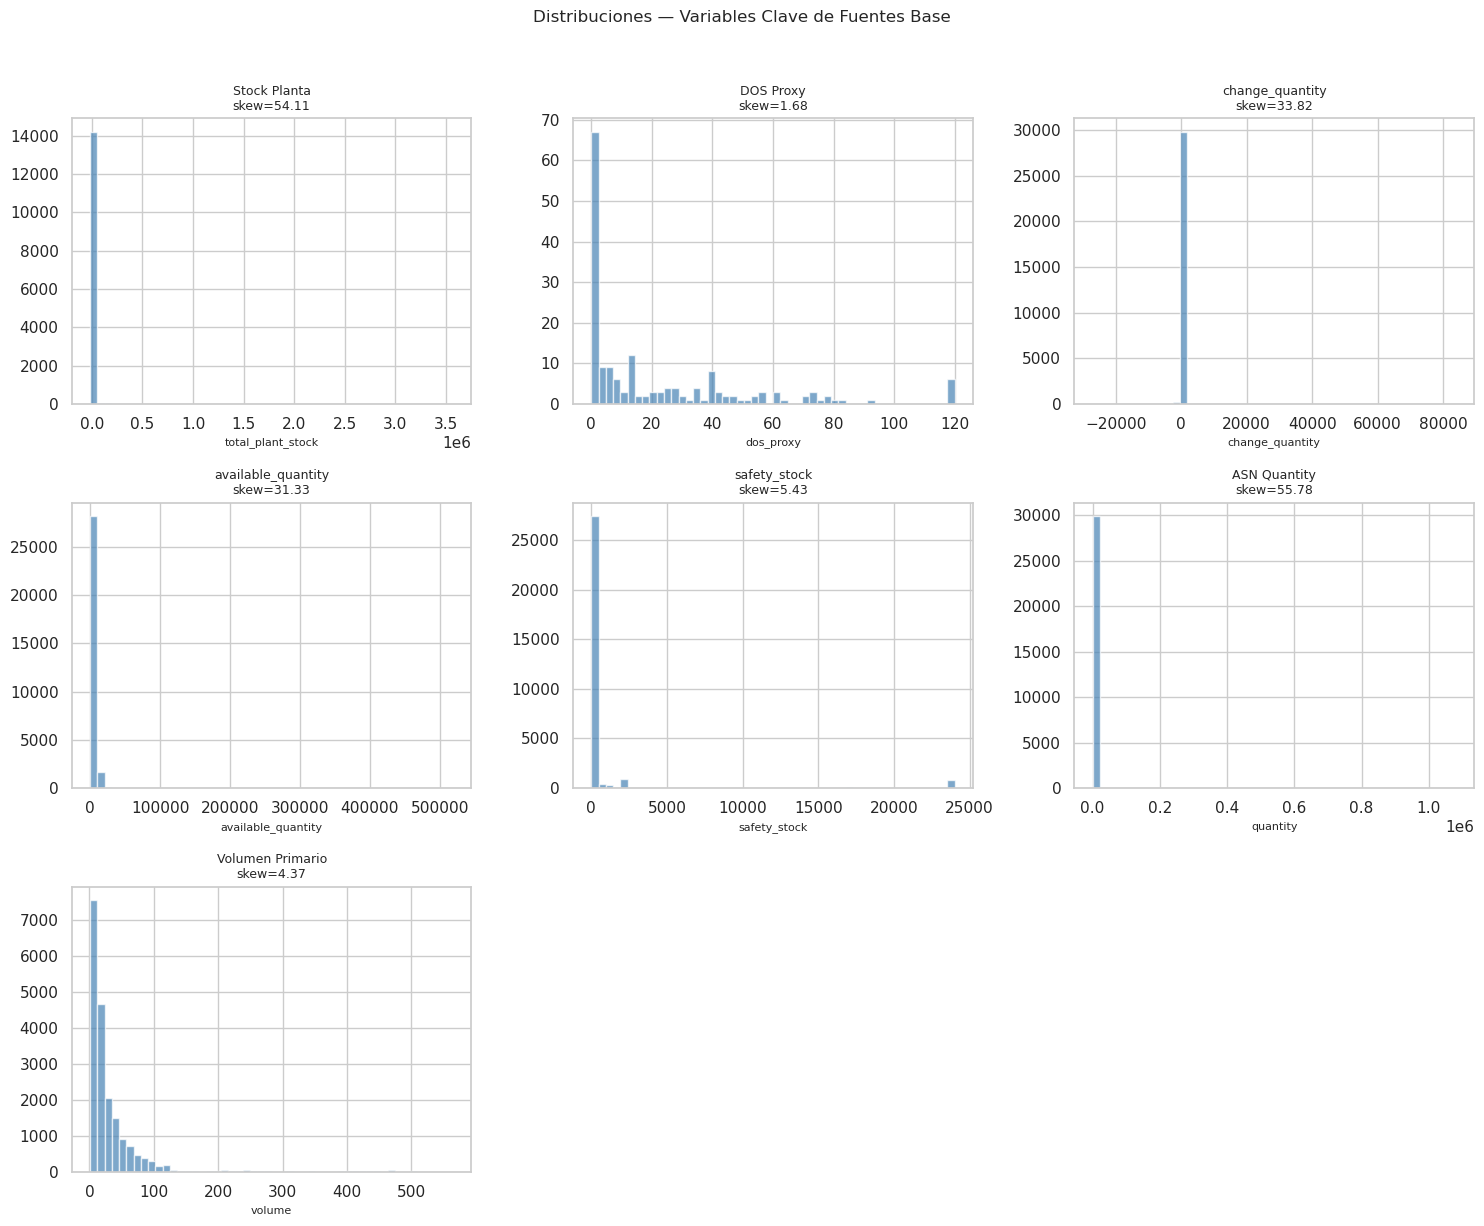

In [21]:
# ── Histogramas de variables clave ──
key_vars = []

if 'total_plant_stock' in df_dos_snap.columns:
    key_vars.append(('total_plant_stock', df_dos_snap, 'Stock Planta'))
if not dos_proxy.empty and 'dos_proxy' in dos_proxy.columns:
    key_vars.append(('dos_proxy', dos_proxy, 'DOS Proxy'))
for col in ['change_quantity', 'available_quantity', 'safety_stock']:
    if col in df_stock_req.columns:
        sdf_tmp = df_stock_req.sample(min(30000, len(df_stock_req)), random_state=SEED)
        key_vars.append((col, sdf_tmp, col))
if 'quantity' in df_asn.columns:
    key_vars.append(('quantity', df_asn.sample(min(30000, len(df_asn)), random_state=SEED), 'ASN Quantity'))
if 'volume' in df_primary.columns:
    key_vars.append(('volume', df_primary, 'Volumen Primario'))

n = len(key_vars)
if n > 0:
    ncols = min(3, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes_flat = np.atleast_1d(axes).flatten() if n > 1 else [axes]
    for i, (col, data, title) in enumerate(key_vars):
        ax = axes_flat[i]
        vals = data[col].astype('float64').dropna()
        ax.hist(vals, bins=50, edgecolor='white', alpha=0.7, color='steelblue')
        ax.set_title(f'{title}\nskew={vals.skew():.2f}', fontsize=9)
        ax.set_xlabel(col, fontsize=8)
    for j in range(n, len(axes_flat)):
        axes_flat[j].set_visible(False)
    plt.suptitle('Distribuciones — Variables Clave de Fuentes Base', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


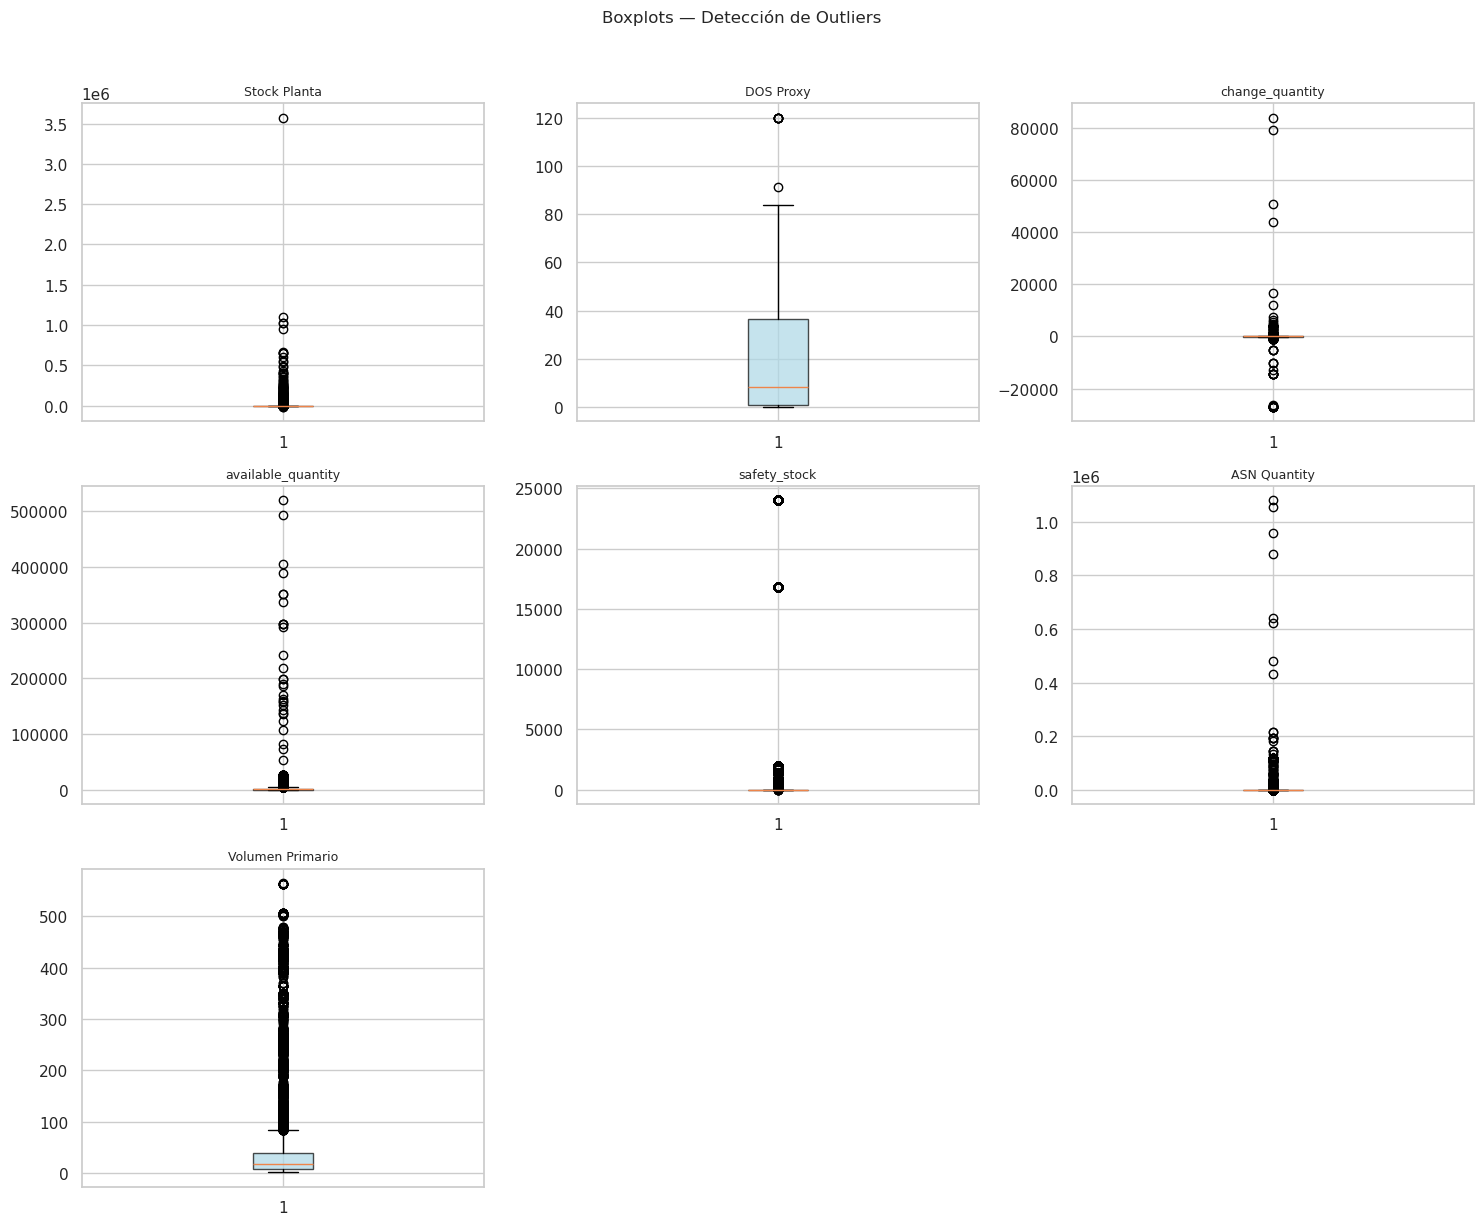

In [22]:
# ── Boxplots ──
if key_vars:
    n = len(key_vars)
    ncols = min(3, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes_flat = np.atleast_1d(axes).flatten() if n > 1 else [axes]
    for i, (col, data, title) in enumerate(key_vars):
        ax = axes_flat[i]
        vals = data[col].astype('float64').dropna()
        bp = ax.boxplot(vals, vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightblue', alpha=0.7))
        ax.set_title(title, fontsize=9)
    for j in range(n, len(axes_flat)):
        axes_flat[j].set_visible(False)
    plt.suptitle('Boxplots — Detección de Outliers', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


In [23]:
# ── Outliers IQR ──
print('=' * 65)
print('  DETECCIÓN DE OUTLIERS (IQR)')
print('=' * 65)
for col, data, title in key_vars:
    vals = data[col].astype('float64').dropna()
    Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = vals[(vals < lower) | (vals > upper)]
    pct = len(outliers) / len(vals) * 100
    print(f'  {title:25s}  Q1={Q1:>10.1f}  Q3={Q3:>10.1f}  IQR={IQR:>10.1f}  '
          f'Outliers={len(outliers):>6,} ({pct:.1f}%)')


  DETECCIÓN DE OUTLIERS (IQR)
  Stock Planta               Q1=       0.0  Q3=     280.0  IQR=     280.0  Outliers= 2,486 (17.3%)
  DOS Proxy                  Q1=       0.7  Q3=      36.7  IQR=      36.0  Outliers=     7 (4.0%)
  change_quantity            Q1=     -12.0  Q3=      -1.0  IQR=      11.0  Outliers= 7,008 (23.4%)
  available_quantity         Q1=      74.0  Q3=    1678.2  IQR=    1604.2  Outliers= 4,326 (14.4%)
  safety_stock               Q1=       0.0  Q3=       0.0  IQR=       0.0  Outliers= 5,941 (19.8%)
  ASN Quantity               Q1=       0.0  Q3=      28.0  IQR=      28.0  Outliers= 5,026 (16.8%)
  Volumen Primario           Q1=       8.0  Q3=      38.0  IQR=      30.0  Outliers= 1,859 (9.3%)


---
## 6. Análisis Temporal
Evolución del stock de planta a lo largo de los últimos 30 días
(desde `days_of_supply_historical`).


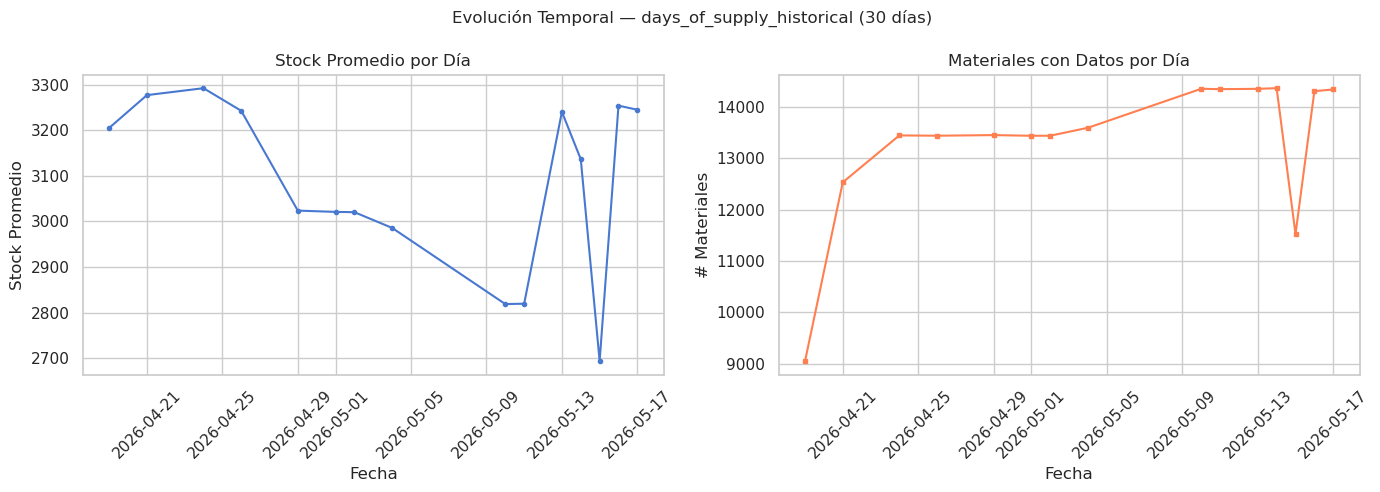

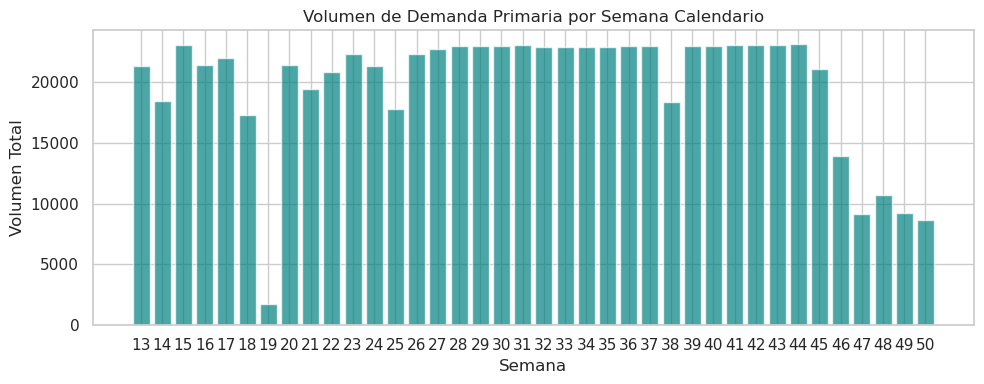

In [24]:
if 'total_plant_stock' in df_dos_hist.columns and 'process_date' in df_dos_hist.columns:
    stock_daily = df_dos_hist.groupby('process_date')['total_plant_stock'].agg(
        ['mean', 'median', 'sum', 'count']).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(stock_daily['process_date'], stock_daily['mean'], marker='o', markersize=3)
    axes[0].set_title('Stock Promedio por Día')
    axes[0].set_xlabel('Fecha')
    axes[0].set_ylabel('Stock Promedio')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].plot(stock_daily['process_date'], stock_daily['count'], marker='s',
                 markersize=3, color='coral')
    axes[1].set_title('Materiales con Datos por Día')
    axes[1].set_xlabel('Fecha')
    axes[1].set_ylabel('# Materiales')
    axes[1].tick_params(axis='x', rotation=45)

    plt.suptitle('Evolución Temporal — days_of_supply_historical (30 días)', fontsize=12)
    plt.tight_layout()
    plt.show()

if 'calendar_week' in df_primary.columns and 'volume' in df_primary.columns:
    weekly = df_primary.groupby('calendar_week')['volume'].sum().reset_index()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(weekly['calendar_week'].astype(str), weekly['volume'], color='teal', alpha=0.7)
    ax.set_title('Volumen de Demanda Primaria por Semana Calendario')
    ax.set_xlabel('Semana')
    ax.set_ylabel('Volumen Total')
    plt.tight_layout()
    plt.show()


---
## 7. Análisis Bivariado / Multivariado
Merge de fuentes clave para analizar correlaciones y relaciones entre variables.


In [25]:
# ── Construcción del dataset integrado ──
df_int = df_dos_snap[['material', 'total_plant_stock']].copy()
df_int['total_plant_stock'] = pd.to_numeric(df_int['total_plant_stock'], errors='coerce')

if 'change_quantity' in df_stock_req.columns:
    sr = df_stock_req.copy()
    sr['change_quantity'] = pd.to_numeric(sr['change_quantity'], errors='coerce')
    dem_agg = sr.groupby('material').agg(
        total_demand=('change_quantity', 'sum'),
        demand_count=('change_quantity', 'count'),
    ).reset_index()
    if 'safety_stock' in sr.columns:
        sr['safety_stock'] = pd.to_numeric(sr['safety_stock'], errors='coerce')
        ss = sr.groupby('material')['safety_stock'].first().reset_index()
        dem_agg = dem_agg.merge(ss, on='material', how='left')
    df_int = df_int.merge(dem_agg, on='material', how='inner')

df_int = df_int.merge(df_cdh[['material', 'concepto']], on='material', how='left')
df_int['concepto'] = df_int['concepto'].fillna('Sin Concepto')

if 'total_demand' in df_int.columns:
    avg_dem = df_int['total_demand'].abs() / df_int['demand_count'].replace(0, np.nan)
    df_int['dos_proxy'] = df_int['total_plant_stock'].astype('float64') / avg_dem.replace(0, np.nan)
    df_int['dos_proxy'] = df_int['dos_proxy'].astype('float64').clip(upper=120)

for c in df_int.select_dtypes(include=[np.number]).columns:
    df_int[c] = df_int[c].astype('float64')

print(f'Dataset integrado: {df_int.shape}')
display(df_int.head())

Dataset integrado: (180, 7)


,material,total_plant_stock,total_demand,demand_count,safety_stock,concepto,dos_proxy
0,5A079A5-02,30.0,-283.0,10.0,0.0,Sin Concepto,1.060071
1,5A079A6-03,28.0,0.0,1465.0,0.0,Sin Concepto,NaN
2,5A079A7-02,16.0,0.0,1350.0,0.0,Sin Concepto,NaN
3,5A079A8-03,18.0,0.0,1350.0,0.0,Sin Concepto,NaN
4,5A079B1-02,0.0,0.0,392.0,0.0,Sin Concepto,NaN


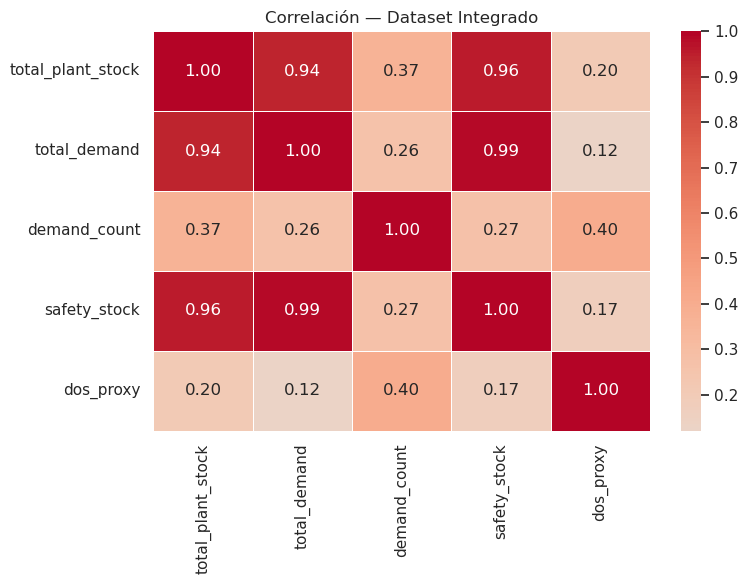


Correlaciones con dos_proxy:
demand_count         0.402
total_plant_stock    0.204
safety_stock         0.166
total_demand         0.121


In [26]:
# ── Correlación ──
num_int = df_int.select_dtypes(include=[np.number])
if num_int.shape[1] >= 2:
    corr = num_int.corr().round(3)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f',
                linewidths=0.5, ax=ax)
    ax.set_title('Correlación — Dataset Integrado')
    plt.tight_layout()
    plt.show()

    if 'dos_proxy' in corr.columns:
        dos_corr = corr['dos_proxy'].drop('dos_proxy', errors='ignore').sort_values(
            key=abs, ascending=False)
        print('\nCorrelaciones con dos_proxy:')
        print(dos_corr.to_string())


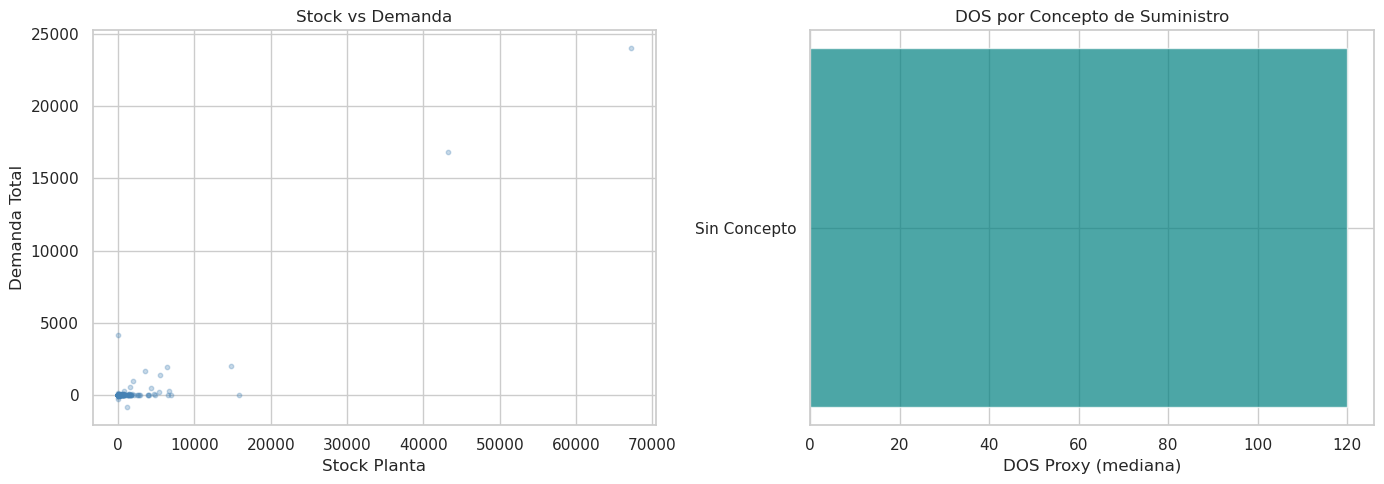

In [27]:
# ── Scatter: Stock vs Demanda + DOS por concepto ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'total_demand' in df_int.columns:
    sample_int = df_int.sample(min(5000, len(df_int)), random_state=SEED)
    axes[0].scatter(sample_int['total_plant_stock'], sample_int['total_demand'],
                    alpha=0.3, s=10, c='steelblue')
    axes[0].set_xlabel('Stock Planta')
    axes[0].set_ylabel('Demanda Total')
    axes[0].set_title('Stock vs Demanda')

if 'dos_proxy' in df_int.columns:
    conceptos = df_int.groupby('concepto')['dos_proxy'].median().sort_values()
    axes[1].barh(conceptos.index, conceptos.values, color='teal', alpha=0.7)
    axes[1].set_xlabel('DOS Proxy (mediana)')
    axes[1].set_title('DOS por Concepto de Suministro')

plt.tight_layout()
plt.show()


---
## 8. Balance de Clases
Discretización del DOS proxy en categorías operativas.


Distribución de categorías DOS:
  Crítico 0-3           3  (  1.7%)  █
  Bajo 3-7              0  (  0.0%)  
  Medio 7-14            0  (  0.0%)  
  Normal 14-30          0  (  0.0%)  
  Alto 30-60            0  (  0.0%)  
  Exceso 60+           30  ( 16.7%)  ████████████████


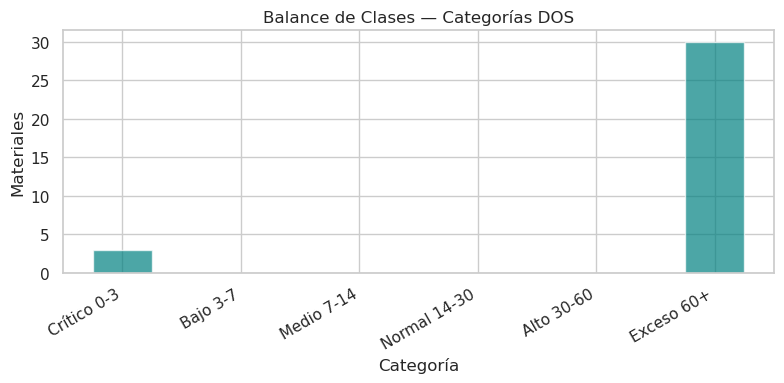

In [28]:
if 'dos_proxy' in df_int.columns:
    bins = [0, 3, 7, 14, 30, 60, 120]
    labels = ['Crítico 0-3', 'Bajo 3-7', 'Medio 7-14',
              'Normal 14-30', 'Alto 30-60', 'Exceso 60+']
    df_int['dos_cat'] = pd.cut(df_int['dos_proxy'], bins=bins, labels=labels)

    cat_counts = df_int['dos_cat'].value_counts().sort_index()
    print('Distribución de categorías DOS:')
    for cat, cnt in cat_counts.items():
        pct = cnt / len(df_int) * 100
        bar = chr(9608) * int(pct)
        print(f'  {str(cat):15s}  {cnt:>6,}  ({pct:5.1f}%)  {bar}')

    fig, ax = plt.subplots(figsize=(8, 4))
    cat_counts.plot(kind='bar', color='teal', alpha=0.7, edgecolor='white', ax=ax)
    ax.set_title('Balance de Clases — Categorías DOS')
    ax.set_xlabel('Categoría')
    ax.set_ylabel('Materiales')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('DOS proxy no disponible para balance de clases.')


---
## 9. Preprocesamiento Aplicado

### Justificación
1. **Nulos:** Imputar columnas numéricas con mediana (robusto ante outliers).
   Columnas categóricas con valor explícito "Desconocido".
2. **Outliers:** Winsorización por IQR (clip al rango [Q1-1.5*IQR, Q3+1.5*IQR])
   para conservar la información sin distorsión extrema.
3. **Normalización:** Estandarización (z-score) para preparar variables para modelos.
4. **Encoding:** One-Hot para `concepto` (baja cardinalidad).

> Se aplica sobre el **dataset integrado** (`df_int`) como demostración del pipeline.


In [29]:
df_pre = df_int.copy()
num_cols = df_pre.select_dtypes(include=[np.number]).columns.tolist()

print('ANTES del preprocesamiento:')
print(f'  Nulos totales: {df_pre[num_cols].isnull().sum().sum()}')

# 1. Imputar nulos numéricos con mediana
for c in num_cols:
    if df_pre[c].isnull().any():
        df_pre[c] = df_pre[c].fillna(df_pre[c].median())

# 2. Winsorización IQR
for c in num_cols:
    vals = df_pre[c].astype('float64')
    Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    before_out = ((vals < lower) | (vals > upper)).sum()
    df_pre[c] = vals.clip(lower=lower, upper=upper)
    if before_out > 0:
        print(f'  Winsorizado {c}: {before_out:,} outliers recortados')

# 3. Estandarización z-score
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
if len(df_pre) > 10 and len(num_cols) > 0:
    df_pre[num_cols] = scaler.fit_transform(df_pre[num_cols])

# 4. One-Hot encoding concepto
if 'concepto' in df_pre.columns:
    dummies = pd.get_dummies(df_pre['concepto'], prefix='concepto', drop_first=True)
    df_pre = pd.concat([df_pre.drop(columns=['concepto']), dummies], axis=1)

print(f'\nDESPUÉS del preprocesamiento:')
print(f'  Nulos totales: {df_pre.select_dtypes(include=[np.number]).isnull().sum().sum()}')
print(f'  Forma: {df_pre.shape}')
display(df_pre.describe().T.round(3))


ANTES del preprocesamiento:
  Nulos totales: 141
  Winsorizado total_plant_stock: 22 outliers recortados
  Winsorizado total_demand: 39 outliers recortados
  Winsorizado demand_count: 10 outliers recortados
  Winsorizado safety_stock: 27 outliers recortados
  Winsorizado dos_proxy: 10 outliers recortados

DESPUÉS del preprocesamiento:
  Nulos totales: 0
  Forma: (180, 7)


,count,mean,std,min,25%,50%,75%,max
total_plant_stock,180.0,0.0,1.003,-0.731,-0.711,-0.587,0.393,2.049
total_demand,180.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000
demand_count,180.0,0.0,1.003,-1.241,-0.788,-0.223,0.495,2.420
safety_stock,180.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000
dos_proxy,180.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000


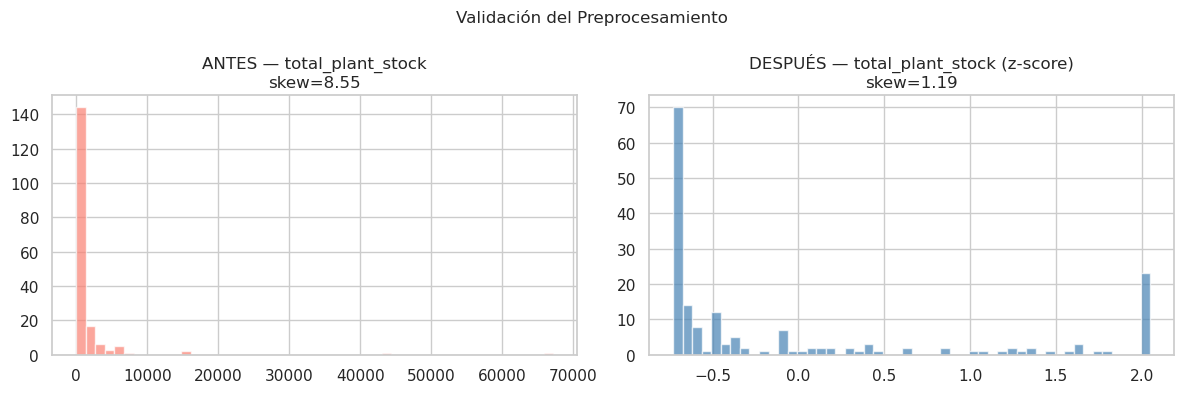

In [30]:
# ── Validación antes / después ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if 'total_plant_stock' in df_int.columns:
    vals_before = df_int['total_plant_stock'].astype('float64').dropna()
    axes[0].hist(vals_before, bins=50, color='salmon', alpha=0.7, edgecolor='white')
    axes[0].set_title(f'ANTES — total_plant_stock\nskew={vals_before.skew():.2f}')

if 'total_plant_stock' in df_pre.columns:
    vals_after = df_pre['total_plant_stock'].dropna()
    axes[1].hist(vals_after, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    axes[1].set_title(f'DESPUÉS — total_plant_stock (z-score)\nskew={vals_after.skew():.2f}')

plt.suptitle('Validación del Preprocesamiento', fontsize=12)
plt.tight_layout()
plt.show()


---
## 10. Selección de Variables (Obj. 2.1)
Identificación de las variables más relevantes para predecir el DOS.


In [31]:
num_pre = df_pre.select_dtypes(include=[np.number])
if 'dos_proxy' in num_pre.columns:
    corr_dos = num_pre.corr()['dos_proxy'].drop('dos_proxy', errors='ignore').dropna()
    corr_dos = corr_dos.reindex(corr_dos.abs().sort_values(ascending=False).index)
    print('Correlación con dos_proxy (ordenada por |r|):')
    for var, r in corr_dos.items():
        bar = chr(9608) * int(abs(r) * 30)
        print(f'  {str(var):30s}  r={r:+.3f}  {bar}')

    print(f'\nVarianza por variable:')
    for c in num_pre.columns:
        v = num_pre[c].var()
        print(f'  {c:30s}  var={v:.4f}')

    selected = [v for v, r in corr_dos.items()
                if abs(r) > 0.1 and num_pre[v].var() > 0.01]
    selected.append('dos_proxy')
    print(f'\nVariables seleccionadas ({len(selected)}): {selected}')
else:
    print('dos_proxy no disponible en df_pre. Revisar integración.')

Correlación con dos_proxy (ordenada por |r|):

Varianza por variable:
  total_plant_stock               var=1.0056
  total_demand                    var=0.0000
  demand_count                    var=1.0056
  safety_stock                    var=0.0000
  dos_proxy                       var=0.0000

Variables seleccionadas (1): ['dos_proxy']


---
## 11. Conclusiones


In [32]:
print('=' * 65)
print('  CONCLUSIONES DEL DIAGNÓSTICO DE FUENTES BASE')
print('=' * 65)

# 1. Estructura
print(f'\n1. ESTRUCTURA DE DATOS')
print(f'   Fuentes analizadas: 6 tablas Athena + 3 archivos S3')
print(f'   Planta: LY78 (San Luis Potosí)')
print(f'   Total filas cargadas: {sum(d.shape[0] for d in [df_dos_hist, df_stock_req, df_asn, matmaster_df, df_cdh, df_primary]):,}')
print(f'   - days_of_supply_historical:    {df_dos_hist.shape[0]:>8,} filas x {df_dos_hist.shape[1]:>3} cols')
print(f'   - stock_req_list_detail_latest:  {df_stock_req.shape[0]:>8,} filas x {df_stock_req.shape[1]:>3} cols')
print(f'   - header_position_p30 (ASN):     {df_asn.shape[0]:>8,} filas x {df_asn.shape[1]:>3} cols')
print(f'   - material_master:               {matmaster_df.shape[0]:>8,} filas x {matmaster_df.shape[1]:>3} cols')
print(f'   - material_master_hist (cdh):    {df_cdh.shape[0]:>8,} filas x {df_cdh.shape[1]:>3} cols')
print(f'   - te_planorder_volume_daily:     {df_primary.shape[0]:>8,} filas x {df_primary.shape[1]:>3} cols')

# 2. Calidad
print(f'\n2. CALIDAD DE DATOS')
for lbl, d in [('dos_hist', df_dos_hist), ('stock_req', df_stock_req),
               ('ASN', df_asn), ('mat_master', matmaster_df)]:
    n_null = (d.isnull().sum() > 0).sum()
    pct_dup = d.duplicated().sum() / len(d) * 100
    print(f'   {lbl:20s}  cols con nulos: {n_null:>3}/{d.shape[1]}   duplicados: {pct_dup:.1f}%')

# 3. Variable objetivo
print(f'\n3. VARIABLE OBJETIVO (DOS)')
print(f'   Materiales en snapshot más reciente ({latest_date}): {df_dos_snap["material"].nunique():,}')
if 'dos_proxy' in df_int.columns:
    dp = df_int['dos_proxy'].dropna()
    print(f'   DOS Proxy calculado para: {len(dp):,} materiales')
    print(f'   Estadísticas: media={dp.mean():.1f}  mediana={dp.median():.1f}  std={dp.std():.1f}')
    print(f'   Rango: [{dp.min():.1f}, {dp.max():.1f}]')

# 4. Distribuciones
print(f'\n4. DISTRIBUCIONES')
if 'total_plant_stock' in df_dos_snap.columns:
    stk = pd.to_numeric(df_dos_snap['total_plant_stock'], errors='coerce').dropna()
    print(f'   Stock planta: skew={stk.skew():.2f} ({"sesgado a la derecha" if stk.skew() > 1 else "moderado"})')
if 'dos_cat' in df_int.columns:
    top_cat = df_int['dos_cat'].value_counts().idxmax()
    top_pct = df_int['dos_cat'].value_counts(normalize=True).max() * 100
    print(f'   Categoría DOS dominante: {top_cat} ({top_pct:.0f}%) → desbalance presente')
print(f'   Outliers detectados (IQR) en variables clave:')
for col, data, title in key_vars[:4]:
    vals = pd.to_numeric(data[col], errors='coerce').dropna()
    Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
    IQR_val = Q3 - Q1
    out_n = ((vals < Q1 - 1.5*IQR_val) | (vals > Q3 + 1.5*IQR_val)).sum()
    print(f'     {title:20s} → {out_n:,} outliers ({out_n/len(vals)*100:.1f}%)')

# 5. Preprocesamiento
print(f'\n5. PREPROCESAMIENTO APLICADO')
print(f'   Dataset integrado: {df_int.shape[0]:,} materiales x {df_int.shape[1]} variables')
print(f'   Post-preprocesamiento: {df_pre.shape[0]:,} filas x {df_pre.shape[1]} cols')
print(f'   Nulos residuales: {df_pre.select_dtypes(include=[np.number]).isnull().sum().sum()}')
if 'concepto' in df_int.columns:
    print(f'   Conceptos codificados (one-hot): {df_int["concepto"].nunique()} categorías')
print(f'   Técnicas: imputación mediana → winsorización IQR → z-score → one-hot')

# 6. Selección
print(f'\n6. SELECCIÓN DE VARIABLES')
if 'dos_proxy' in num_pre.columns:
    corr_final = num_pre.corr()['dos_proxy'].drop('dos_proxy', errors='ignore').dropna()
    top3 = corr_final.abs().sort_values(ascending=False).head(3)
    print(f'   Top correlaciones con DOS proxy:')
    for v, r in top3.items():
        print(f'     {str(v):28s}  |r| = {r:.3f}')
    n_sel = len([v for v, r in corr_final.items() if abs(r) > 0.1 and num_pre[v].var() > 0.01])
    print(f'   Variables seleccionadas (|r|>0.1, var>0.01): {n_sel} + dos_proxy')

print('\n' + '=' * 65)

  CONCLUSIONES DEL DIAGNÓSTICO DE FUENTES BASE

1. ESTRUCTURA DE DATOS
   Fuentes analizadas: 6 tablas Athena + 3 archivos S3
   Planta: LY78 (San Luis Potosí)
   Total filas cargadas: 683,551
   - days_of_supply_historical:     200,000 filas x  22 cols
   - stock_req_list_detail_latest:   200,000 filas x  63 cols
   - header_position_p30 (ASN):      150,000 filas x 102 cols
   - material_master:                113,660 filas x 122 cols
   - material_master_hist (cdh):           1 filas x   4 cols
   - te_planorder_volume_daily:       19,890 filas x   7 cols

2. CALIDAD DE DATOS
   dos_hist              cols con nulos:   5/22   duplicados: 0.0%
   stock_req             cols con nulos:  31/63   duplicados: 0.0%
   ASN                   cols con nulos:  74/102   duplicados: 0.0%
   mat_master            cols con nulos:  72/122   duplicados: 0.0%

3. VARIABLE OBJETIVO (DOS)
   Materiales en snapshot más reciente (2026-05-17): 14,343
   DOS Proxy calculado para: 39 materiales
   Estadística